## scenario 3 = Imbalanced + Preprocessing + drop enhanced_casualty_severity (focus ke imputasi, encoding, scaling tanpa balancing)

In [1]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31984 entries, 0 to 31983
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              30377 non-null  object 
 1   collision_index                     31984 non-null  object 
 2   collision_year                      30370 non-null  float64
 3   collision_reference                 30419 non-null  object 
 4   vehicle_reference                   31984 non-null  float64
 5   casualty_reference                  31984 non-null  float64
 6   casualty_class                      31984 non-null  int64  
 7   sex_of_casualty                     30372 non-null  float64
 8   age_of_casualty                     31983 non-null  float64
 9   age_band_of_casualty                31983 non-null  float64
 10  pedestrian_location                 31983 non-null  float64
 11  pedestrian_movement                 31983

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,30370.0,31984.000000,31984.000000,31984.000000,30372.000000,31983.000000,31983.000000,31983.000000,31983.000000,31983.000000,31983.000000,30387.000000,31983.000000,30382.000000,31983.000000,31983.000000,31983.000000
mean,2024.0,1.456264,1.354857,1.488807,1.365007,37.037082,6.314886,0.800435,0.657756,0.199794,0.060282,0.031691,9.284589,0.990257,4.134884,1.582622,2.882219
std,0.0,1.578505,0.869872,0.733253,0.580021,19.888296,2.504675,2.209387,2.047096,0.649541,0.476572,0.288351,15.738786,0.974091,3.291253,2.272240,0.363391
min,2024.0,0.462251,0.595566,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,22.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [2]:
#Cek missing values

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()


status                                1607
collision_year                        1614
collision_reference                   1565
sex_of_casualty                       1612
age_of_casualty                          1
age_band_of_casualty                     1
pedestrian_location                      1
pedestrian_movement                      1
car_passenger                            1
bus_or_coach_passenger                   1
pedestrian_road_maintenance_worker    1597
casualty_type                            1
casualty_home_area_type               1602
casualty_imd_decile                      1
lsoa_of_casualty                         1
enhanced_casualty_severity               1
casualty_severity                        1
dtype: int64


,0
status,1607
collision_index,0
collision_year,1614
collision_reference,1565
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,1612
age_of_casualty,1
age_band_of_casualty,1


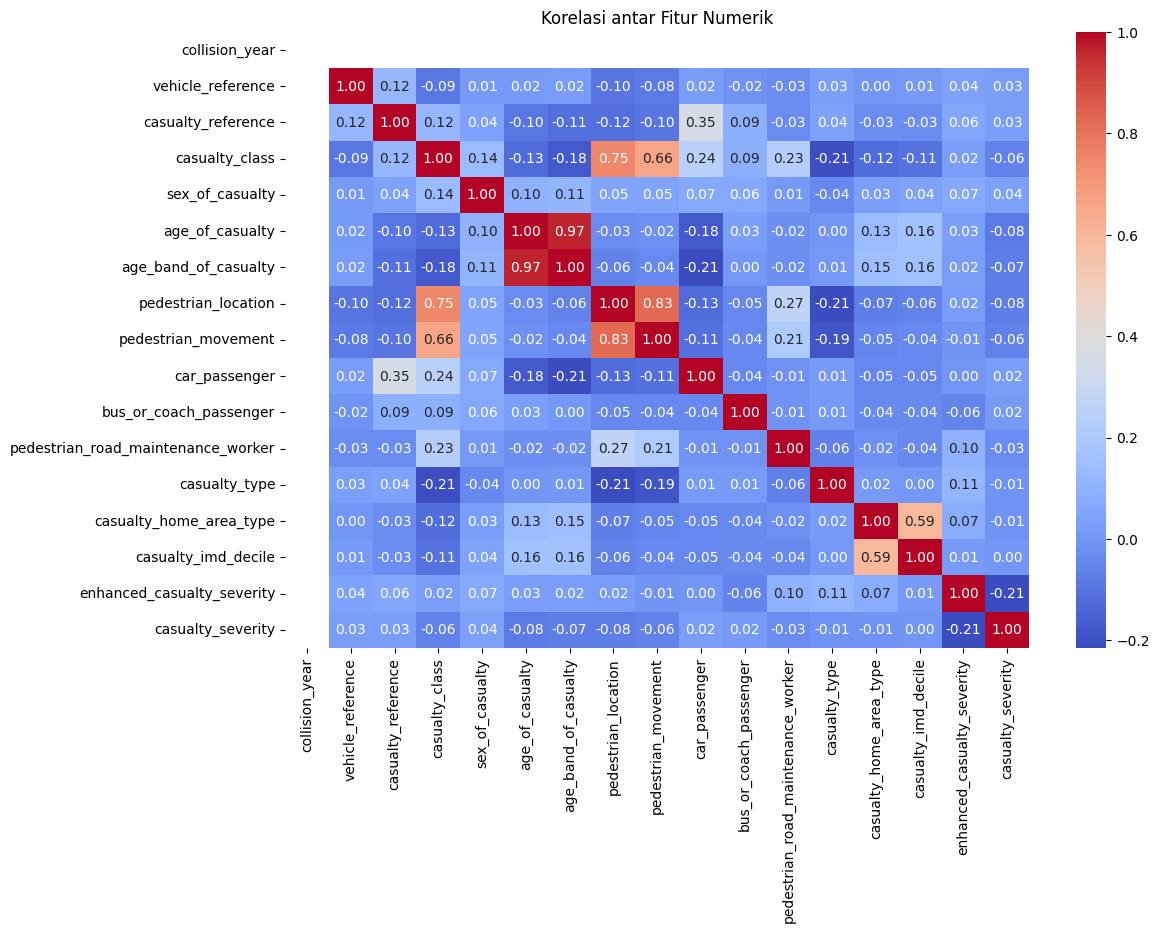

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()


In [4]:
import numpy as np

df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty","age_band_of_casualty","enhanced_casualty_severity","collision_index"], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

# Identifikasi nilai absurd
mask_invalid = df['pedestrian_location'] > 100

# Ganti nilai absurd dengan 0 atau NaN jika tidak bisa dipercaya
df.loc[mask_invalid, 'pedestrian_location'] = 0

# Set pedestrian_location = 0 bila pedestrian_movement == 0
df.loc[df['pedestrian_movement'] == 0, 'pedestrian_location'] = 0

# Gabungkan sebagai string lalu encode dan drop kolom aslinya
df['pedestrian_context'] = df['pedestrian_location'].astype(str) + "_" + df['pedestrian_movement'].astype(str)
df.drop(columns=['pedestrian_location', 'pedestrian_movement'], inplace=True)

# Ganti nilai tidak valid dengan NaN
df['casualty_home_area_type'].replace([-10, 10, 20, 30], np.nan, inplace=True)
df['casualty_imd_decile'].replace(-1, np.nan, inplace=True)

# Imputasi NaN dengan modus
home_mode = df['casualty_home_area_type'].mode()[0]
imd_mode = df['casualty_imd_decile'].mode()[0]

df['casualty_home_area_type'].fillna(home_mode, inplace=True)
df['casualty_imd_decile'].fillna(imd_mode, inplace=True)


missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

age_of_casualty           1
car_passenger             1
bus_or_coach_passenger    1
casualty_type             1
casualty_severity         1
dtype: int64


/tmp/ipython-input-4-3237322194.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
/tmp/ipython-input-4-3237322194.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,1
car_passenger,1
bus_or_coach_passenger,1
pedestrian_road_maintenance_worker,0
casualty_type,1
casualty_home_area_type,0


In [5]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['casualty_severity'])
y = df['casualty_severity'] - 1  # ubah label dari [1,2,3] jadi [0,1,2]


In [6]:
categorical_features = [
    'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty',
    'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker',
    'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'pedestrian_context'
]
numerical_features = ['age_of_casualty']


In [7]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Encode
ord_enc = OrdinalEncoder()
X[categorical_features] = ord_enc.fit_transform(X[categorical_features])

# Scale
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
import pandas as pd

# Hapus baris dengan target kosong
df = df.dropna(subset=["casualty_severity"])

# Salin data
train = df.copy()
X = train.drop(columns=['casualty_severity'])
y = train['casualty_severity'] - 1  # Encoding label

# Label encoding
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Daftar semua model
classifiers = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=random_state)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("ExtraTrees", ExtraTreesClassifier(random_state=random_state)),
    ("Bagging", BaggingClassifier(random_state=random_state)),
    ("AdaBoost", AdaBoostClassifier(random_state=random_state)),
    ("GradientBoost", GradientBoostingClassifier(random_state=random_state)),
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=random_state)),
    ("XGBoost", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis())
]

# Voting classifier
voting = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ('gb', GradientBoostingClassifier(random_state=random_state)),
    ('rf', RandomForestClassifier(random_state=random_state))
], voting='soft')

classifiers.append(("Voting", voting))

# Evaluasi cross-validation
cv_results = []
for name, model in classifiers:
    try:
        scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=kfold, n_jobs=-1)
        cv_results.append((name, scores.mean(), scores.std()))
    except Exception as e:
        print(f"Model {name} gagal dievaluasi: {e}")

# Hasil evaluasi
cv_res = pd.DataFrame(cv_results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
cv_res = cv_res.sort_values(by='CrossValMeans', ascending=False)
print("Fitur yang digunakan:\n", X.columns.tolist())
print(cv_res)


Fitur yang digunakan:
 ['vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'pedestrian_context']
             Algorithm  CrossValMeans  CrossValStd
0   LogisticRegression       0.896271     0.000077
7             AdaBoost       0.896271     0.000077
11                 LDA       0.896271     0.000077
9    HistGradientBoost       0.896076     0.000259
8        GradientBoost       0.895294     0.000825
13              Voting       0.894943     0.000676
10             XGBoost       0.892558     0.000976
1                  KNN       0.884195     0.001200
4        Random Forest       0.872313     0.001601
5           ExtraTrees       0.853240     0.002237
6              Bagging       0.853045     0.003231
3        Decision Tree       0.805128     0.001689
2           GaussianNB       0.702840     0.

In [11]:
!pip install optuna

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === Tuning AdaBoost ===
def objective_ada(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 2.0)
    }
    model = AdaBoostClassifier(random_state=42, **params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_ada = optuna.create_study(direction="maximize")
study_ada.optimize(objective_ada, n_trials=30)

# === Tuning LDA ===
def objective_lda(trial):
    solver = trial.suggest_categorical("solver", ["svd", "lsqr", "eigen"])
    shrinkage = None
    if solver in ["lsqr", "eigen"]:
        shrinkage = trial.suggest_categorical("shrinkage", ["auto", 0.0, 0.1, 0.5, 1.0])

    params = {"solver": solver}
    if shrinkage is not None:
        params["shrinkage"] = shrinkage

    model = LinearDiscriminantAnalysis(**params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_lda = optuna.create_study(direction="maximize")
study_lda.optimize(objective_lda, n_trials=30)

# === Tuning Logistic Regression ===
def objective_logreg(trial):
    params = {
        "C": trial.suggest_float("C", 0.001, 10.0, log=True),
        "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
        "penalty": "l2"
    }
    model = LogisticRegression(**params, max_iter=1000, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_logreg = optuna.create_study(direction="maximize")
study_logreg.optimize(objective_logreg, n_trials=30)

print("=== Best AdaBoost Hyperparameters ===")
print(study_ada.best_params)
print("Best AdaBoost Accuracy:", study_ada.best_value)

print("\n=== Best LDA Hyperparameters ===")
print(study_lda.best_params)
print("Best LDA Accuracy:", study_lda.best_value)

print("\n=== Best Logistic Regression Hyperparameters ===")
print(study_logreg.best_params)
print("Best Logistic Regression Accuracy:", study_logreg.best_value)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 14.4 MB/s eta 0:00:00


[I 2025-06-23 11:49:02,437] A new study created in memory with name: no-name-54e5d703-61e8-490a-bf5e-0e970aa3dbbf
[I 2025-06-23 11:49:14,171] Trial 0 finished with value: 0.8962713993146538 and parameters: {'n_estimators': 225, 'learning_rate': 1.0237004286429738}. Best is trial 0 with value: 0.8962713993146538.
[I 2025-06-23 11:49:22,305] Trial 1 finished with value: 0.895919638337082 and parameters: {'n_estimators': 149, 'learning_rate': 1.8186049122918433}. Best is trial 0 with value: 0.8962713993146538.
[I 2025-06-23 11:49:26,465] Trial 2 finished with value: 0.8962713993146538 and parameters: {'n_estimators': 86, 'learning_rate': 1.5195602397720505}. Best is trial 0 with value: 0.8962713993146538.
[I 2025-06-23 11:49:35,228] Trial 3 finished with value: 0.8960759723066414 and parameters: {'n_estimators': 163, 'learning_rate': 0.8033950751592028}. Best is trial 0 with value: 0.8962713993146538.
[I 2025-06-23 11:49:42,679] Trial 4 finished with value: 0.8962713993146538 and paramete

=== Best AdaBoost Hyperparameters ===
{'n_estimators': 142, 'learning_rate': 1.7579993682585682}
Best AdaBoost Accuracy: 0.8963495548441575

=== Best LDA Hyperparameters ===
{'solver': 'svd'}
Best LDA Accuracy: 0.8962713993146538

=== Best Logistic Regression Hyperparameters ===
{'C': 2.808440047272825, 'solver': 'lbfgs'}
Best Logistic Regression Accuracy: 0.8962713993146538


In [13]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# === Model 1: AdaBoost ===
ada_best = AdaBoostClassifier(
    n_estimators=142,
    learning_rate=1.7579993682585682,
    random_state=42
)
ada_best.fit(X_train, y_train)
y_pred_ada = ada_best.predict(X_test)

print("=== AdaBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

# === Model 2: LDA ===
lda_best = LinearDiscriminantAnalysis(
    solver='svd'  # Tidak boleh ada shrinkage!
)
lda_best.fit(X_train, y_train)
y_pred_lda = lda_best.predict(X_test)

print("\n=== LDA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

# === Model 3: Logistic Regression ===
logreg_best = LogisticRegression(
    C=2.808440047272825,
    solver='lbfgs',
    penalty='l2',
    max_iter=1000,
    random_state=42
)
logreg_best.fit(X_train, y_train)
y_pred_log = logreg_best.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== AdaBoost ===
Accuracy: 0.8963576676567141
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        90
         1.0       0.00      0.00      0.00       573
         2.0       0.90      1.00      0.95      5734

    accuracy                           0.90      6397
   macro avg       0.30      0.33      0.32      6397
weighted avg       0.80      0.90      0.85      6397



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== LDA ===
Accuracy: 0.8963576676567141
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        90
         1.0       0.00      0.00      0.00       573
         2.0       0.90      1.00      0.95      5734

    accuracy                           0.90      6397
   macro avg       0.30      0.33      0.32      6397
weighted avg       0.80      0.90      0.85      6397



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Logistic Regression ===
Accuracy: 0.8963576676567141
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        90
         1.0       0.00      0.00      0.00       573
         2.0       0.90      1.00      0.95      5734

    accuracy                           0.90      6397
   macro avg       0.30      0.33      0.32      6397
weighted avg       0.80      0.90      0.85      6397



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

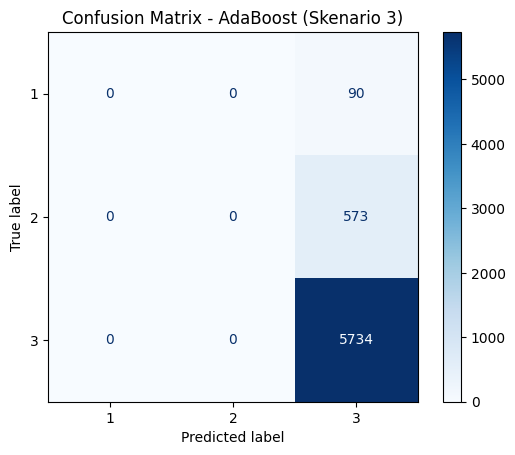

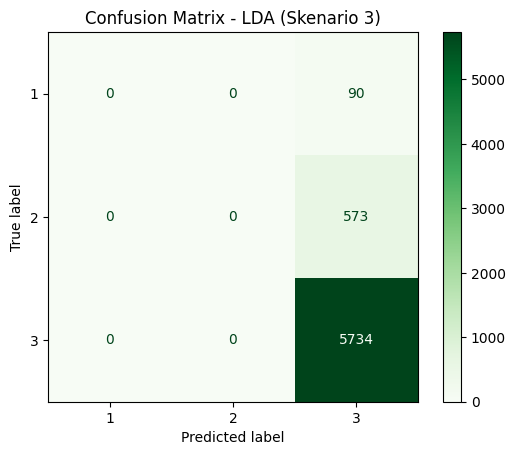

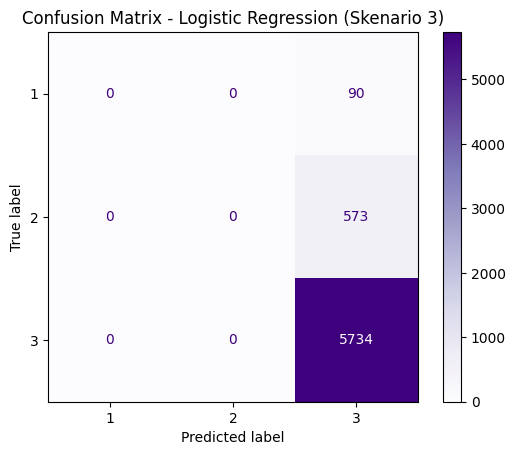

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === Confusion Matrix: AdaBoost ===
cm_ada = confusion_matrix(y_test, y_pred_ada)
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=[1, 2, 3])
disp_ada.plot(cmap='Blues')
plt.title("Confusion Matrix - AdaBoost (Skenario 3)")
plt.show()

# === Confusion Matrix: LDA ===
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=[1, 2, 3])
disp_lda.plot(cmap='Greens')
plt.title("Confusion Matrix - LDA (Skenario 3)")
plt.show()

# === Confusion Matrix: Logistic Regression ===
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=[1, 2, 3])
disp_log.plot(cmap='Purples')
plt.title("Confusion Matrix - Logistic Regression (Skenario 3)")
plt.show()
